# Learning and Regret

*Andrew Wang · 2026-08-08*

## Contents

1. [Introduction](#introduction)
2. [Baseline Strategies](#baseline-strategies)
3. [Explore then Exploit vs $\epsilon$-greedy](#explore-exploit-vs-eps-greedy)
    1. [Explore then Exploit](#explore-then-exploit)
    2. [$\epsilon$-greedy](#eps-greedy)
    3. [Experimentation](#experimentation)
4. [Optimal $\epsilon$?](#optimal-epsilon)
5. [Thompson Sampling](#thompson-sampling)
6. [What's next](#whats-next)

<a id="introduction"></a>
## Introduction

It is important and interesting to think about how we can measure the performance of different strategies. The obvious thing would be the end PnL, and perhaps averaged over many seeds. However, we also want to visualize how _quickly_ the strategy learns. In other words, it is not enough to measure which strategies acumulates most PnL in the end, but how fast they do this. Moreover, merely measuring the PnL differences will not be very enlightening as will be shown later, and will not be a very effective performance differentiator. So, we introduce the quantity of regret. We define the regret as a function that takes in the true popping probability $p$, true popping value $v$ and a strategy's PnL gain from a single balloon $g$:
$
\begin{equation}
    regret(p, g) = r(p, g) = \mathbb{1} \left \{ \left \lceil \frac{1-p}{p} \right \rceil < v \right \} \times \left \lceil \frac{1-p}{p} \right \rceil - g
\end{equation}
$

Or in other words, the regret of a strategy is the difference between the PnL gain of an oracle strategy that knows the true popping probabilities and its own PnL gain. The quantity we really care about is the cumulative regret, the definition of which is self-explanatory. Importantly though, we can notice now that despite knowing the true probabilities, a strastegy still might just get _unlucky_. This introduces a source of noise in our data. To remove this, we can compute the _expected_ regret or also sometimes called _pseudo_regret. The definition of which is:

$
\begin{equation}
    r_e(p, g, k) = \mathbb{E}[r(p, g)] = \left \lceil \frac{1-p}{p} \right \rceil (1-p)^{\left \lceil \frac{1-p}{p} \right \rceil} - k(1-p)^{k}
\end{equation}
$
where $k$ is the threshold that the strategy proposes. 

Another metric that we should measure is the following. It is clear that a good strategy should over the long run converge to the _correct_ threshold, i.e 
$\begin{equation}
\left \lceil \frac{1-p}{p} \right \rceil 
\end{equation}
$
So, it might be a good metric to measure the difference between a strategy's threshold and the correct threshold. We can call this quantity $d$:
$\begin{equation}
d(k, p) = \left(k-\left \lceil \frac{1-p}{p} \right \rceil \right)^2
\end{equation}
$
where $k$ is still the same $k$ (the strategy's threshold). Computation of these metrics can be found in _metrics.py_ in the modules folder.

<a id="baseline-strategies"></a>
## Baseline Strategies

The most basic strategy one can think of is to "just guess". In other words, at each balloon, pick a random number of pumps between 1 and $n$. There is no particular canonical choice for $n$, theire performances would merely depend on how the true probabilities are distributed. Another obvious strategy is to assume that the average type of balloon has a $50%$ popping probability, and would therefore in expectation pop after $2$ pumps. In this case, always pumping once would be the strategy. We can plot their performances:

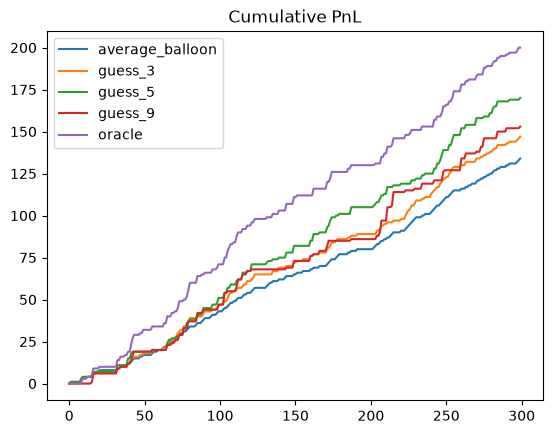

In [2]:

import os
import sys
MODULES_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "modules"))
if MODULES_DIR not in sys.path:
    sys.path.insert(0, MODULES_DIR)

from plotting import plot_PnL_curves

plot_PnL_curves("baseline_strategies")

From this graph alone, it would seem like all of these strategies are performing similarly, with perhaps the blue one being slightly worse than the others and the green being slightly better. However, if we plot the realized cumulative regret, we obtain the following plot:

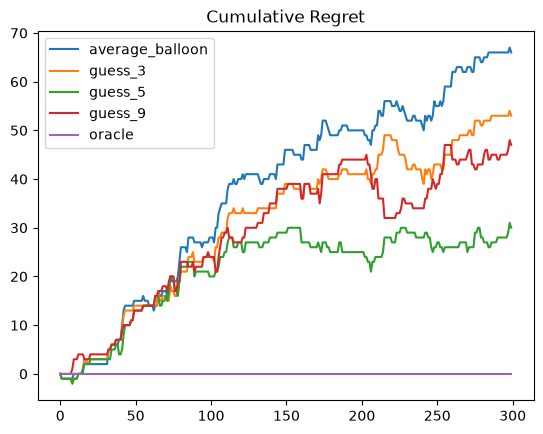

In [3]:
from plotting import plot_regret_curves

plot_regret_curves("baseline_strategies")

Since we want to minimize regret, we can now much more clearly see that the green strategy is doing a lot better than the others, especially midgame. Of course, this could very likely be an artifact of this specific game seed, and the natural step is then to average over many seeds. But, the main point that I'm trying to make here is that, although in the first plot of cumulative PnL, the purple (Oracle) strategy is barely doing better than the others, we can see this effect extremely clear in the Cumulative Regret plot. If we average over $50% seeds, we produce the following plots:

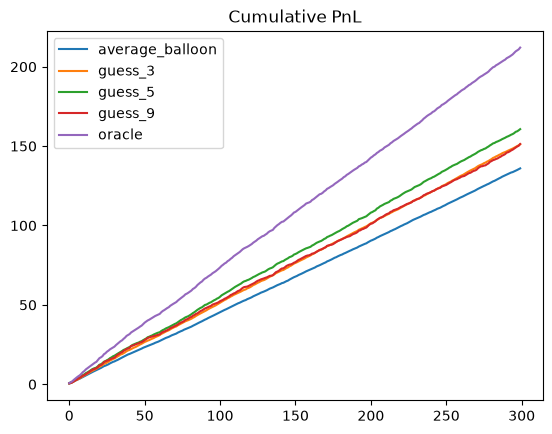

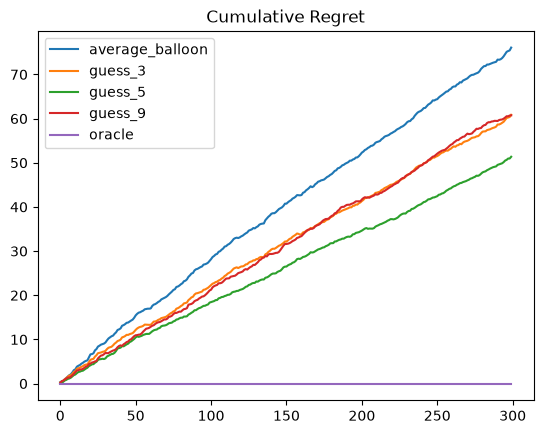

In [4]:
plot_PnL_curves("baseline_strategies_avg")
plot_regret_curves("baseline_strategies_avg")

We can see that the noise is significantly reduced as expected. Plotting these somewhat stupid strategies was mainly to demonstrate the machinery we will use to analyze the performance of the strategies. In the next section, we will analyze more rational and sophisticated strategies.

<a id="explore-exploit-vs-eps-greedy"></a>
## Explore then Exploit vs $\epsilon$-greedy


In the very beginning, we mentioned that one of the most intuitive strategies to this game would be to spend the first part of the game _exploring_, then spending the rest _exploiting_. After reading some of the literature on topics similar to this, the most cited strategy was called $\epsilon$-greedy. Instead of having a long exploration phase in the beginning of the game, at each point in the game there would be a coin flip (not necessarily fair) on whether the strategy would explore or exploit. It is perhaps more clear if we formalize these strategies

<a id="explore-then-exploit"></a>
### Explore then Exploit
This strategy takes in a single parameter _ratio_, which we will denote $\epsilon$. Suppose there are $N$ balloons total, then for the first $\epsilon N$ of them, we will _explore_. This consists of _always_ pumping. For each color $c$ we will compute the estimated probability $p_c$. If we have successfully pumped this balloon $a$ times and failed $b$ times during the exploration phase, 

\begin{equation}
p_c = \frac{b+1}{a+b+2}
\end{equation}

This is equivalent to Bayesian updating starting with a uniform prior. Then, for the remaining balloons of the game the threshold will submit the threshold 
$
\begin{equation}
threshold = \left \lceil \frac{1-p_c}{p_c} \right \rceil
\end{equation}
$


<a id="eps-greedy"></a>
### $\epsilon$-greedy
This strategy also takes in a single parameter $\epsilon$. At each balloon, there is an $\epsilon$ probability that the strategy will _explore_. Like the previous strategy, this consists of just always pumping. On the other hand, at each balloon, there is a $1-\epsilon$ probability that the strategy will _exploit_. This would consist of submitting the threshold using its best estimate of the the popping probability computed in the same way as Explore then Exploit strategy.

It is not clear right away whether these similar strategies are actually equivalent, or that one is better than the other. Although, one could argue that they probably converge in the long run. Let's compare them!

<a id="experimentation"></a>
### Experimentation

Using an $\epsilon = 0.1$ initially, obtain the following:

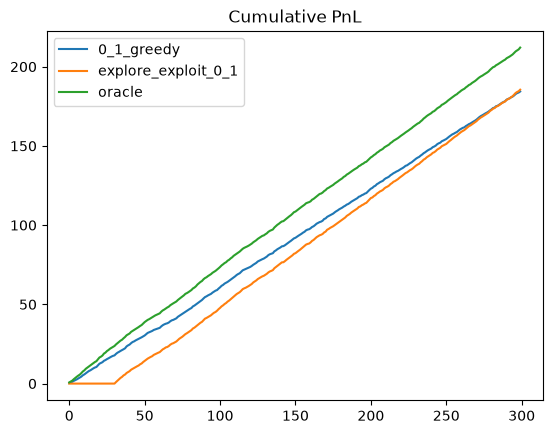

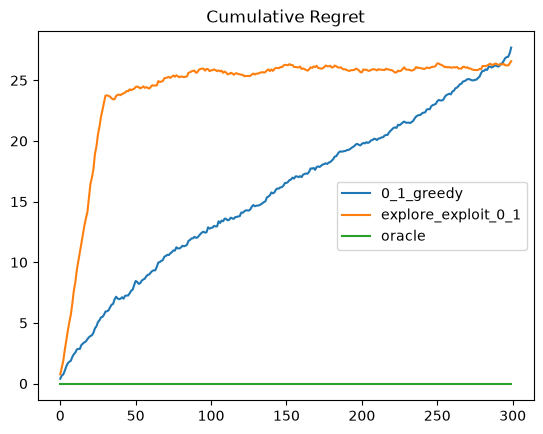

In [5]:
plot_PnL_curves("explore_exploit_vs_eps_greedy")
plot_regret_curves("explore_exploit_vs_eps_greedy")

As we predicted, we can see that the two strategies converge at the end of the game with the same PnL. However, it would be interesting to see how the number of balloons would affect this. So, let's plot $20$, $50$ balloons, $100$ balloons, $200$ balloons, $400$ balloons and $800$ balloons. First, with $20$ balloons, we get the following:

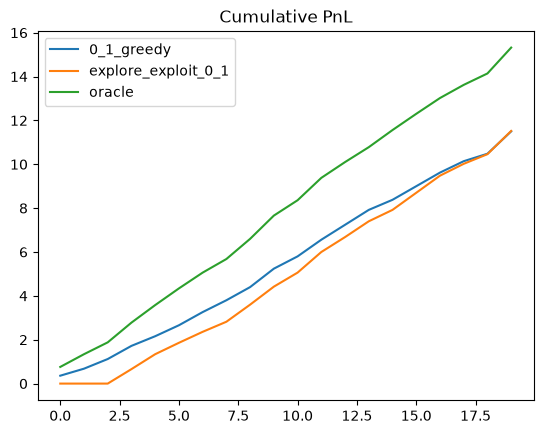

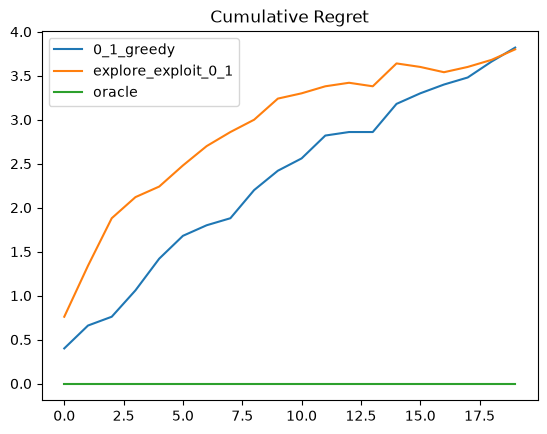

In [6]:
plot_PnL_curves("explore_exploit_vs_eps_greedy_20_balloons")
plot_regret_curves("explore_exploit_vs_eps_greedy_20_balloons")

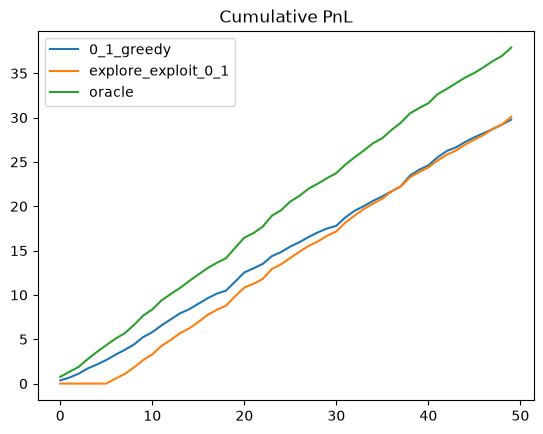

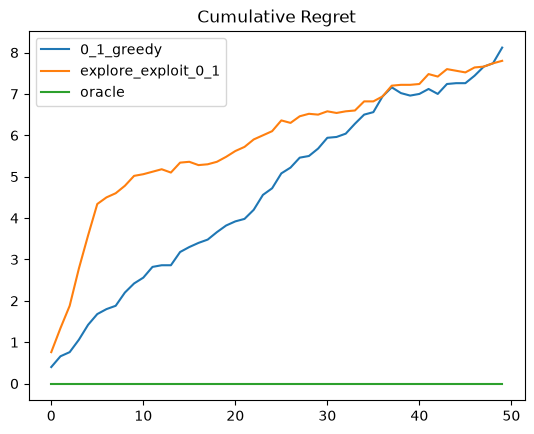

In [7]:
plot_PnL_curves("explore_exploit_vs_eps_greedy_50_balloons")
plot_regret_curves("explore_exploit_vs_eps_greedy_50_balloons")

$100$:

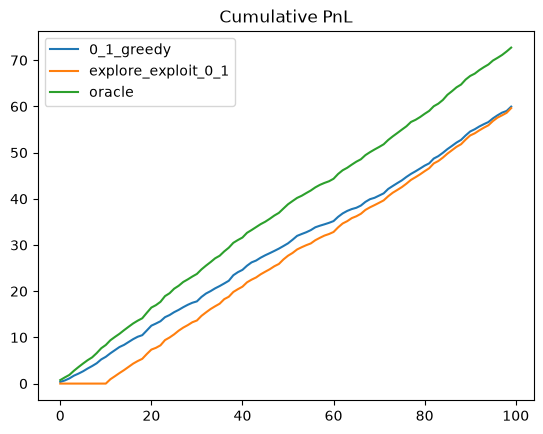

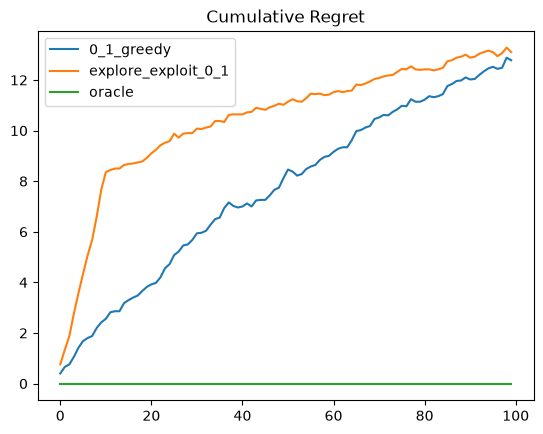

In [8]:
plot_PnL_curves("explore_exploit_vs_eps_greedy_100_balloons")
plot_regret_curves("explore_exploit_vs_eps_greedy_100_balloons")

$200$:

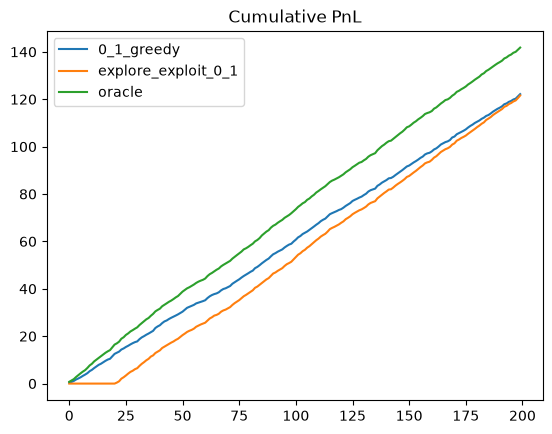

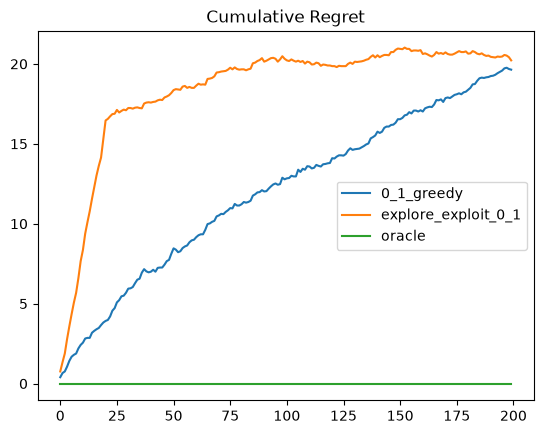

In [9]:
plot_PnL_curves("explore_exploit_vs_eps_greedy_200_balloons")
plot_regret_curves("explore_exploit_vs_eps_greedy_200_balloons")

$400$:

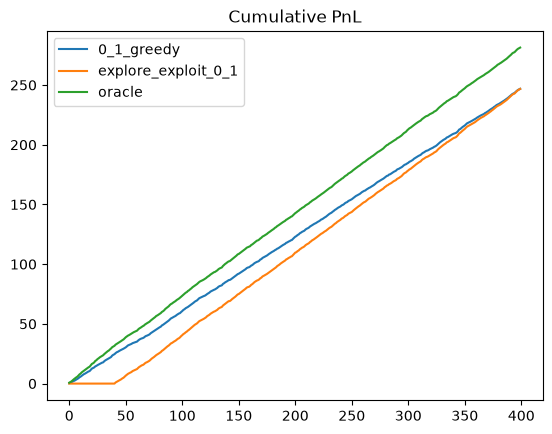

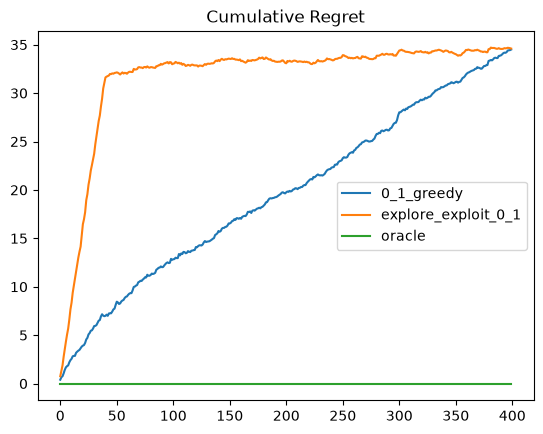

In [10]:
plot_PnL_curves("explore_exploit_vs_eps_greedy_400_balloons")
plot_regret_curves("explore_exploit_vs_eps_greedy_400_balloons")

$800$:

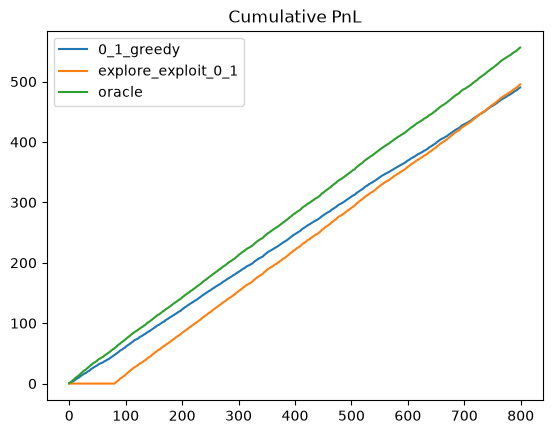

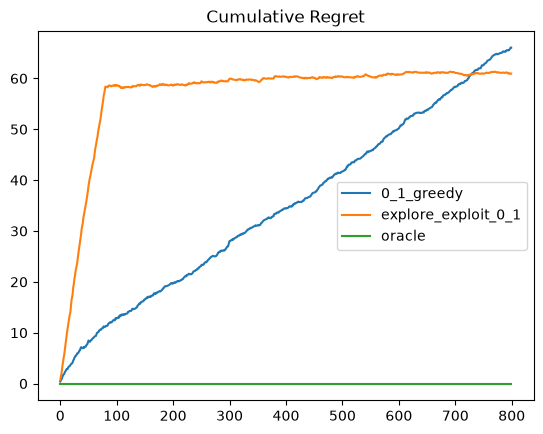

In [11]:
plot_PnL_curves("explore_exploit_vs_eps_greedy_800_balloons")
plot_regret_curves("explore_exploit_vs_eps_greedy_800_balloons")

It seems like these two strategies, compared at the end of the game, are pretty much equivalent, no matter the length of the game. This is somewhat expected as in the long run, the number of exploration rounds, and hence the amount of information gained is the same. Once can maybe note that in the last plot, we can see that there is a slight divergence, but this is really just noise, as one can see if you run more experiments.

<a id="optimal-epsilon"></a>
## Optimal $\epsilon$?


A natural question to ask is whether there exists an optimal $\epsilon$ for which both of the two aforementioned strategies maximize their end PnL, or minimize their cumulative regret. Before optimizing this systematically, let's try to get a ballpark estimate by seeing how they perform against each other.

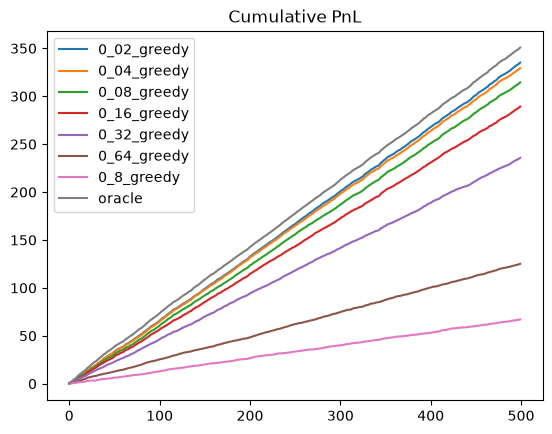

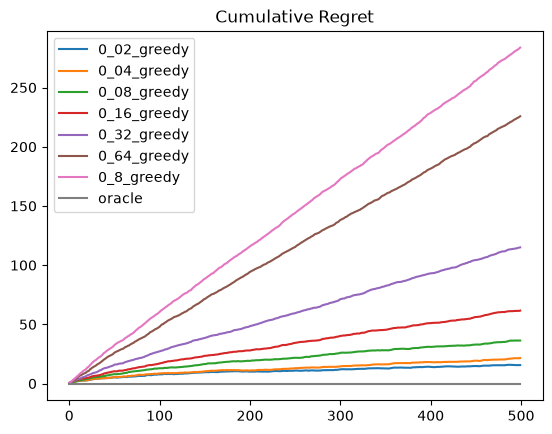

In [12]:
plot_PnL_curves("optimal_eps_500")
plot_regret_curves("optimal_eps_500")

It seems like the lower the value of $\epsilon$ the better the strategy does in the long run. This is not surprising, since a smaller $\epsilon$ means it is _wasting_ only a few percent of its actions. However, we expect the higher epsilon to do better relatively in shorter runs since the strategies would then have a much worse estimate of the popping probabilities. In other words, the cost of _not_ exploring kicks in. Let's try running some shorter games. We can start with $50$ balloons:


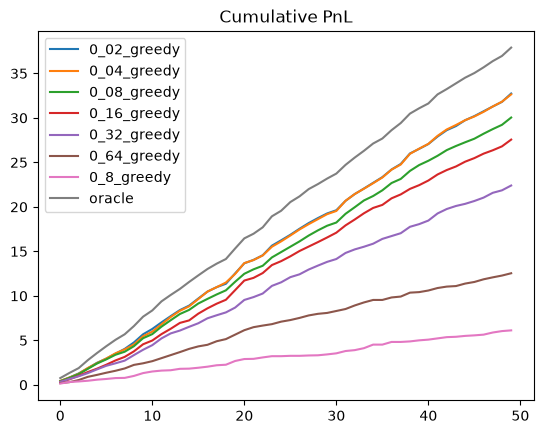

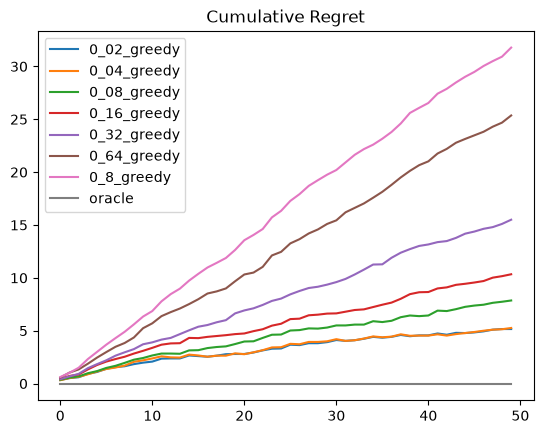

In [13]:
plot_PnL_curves("optimal_eps_50")
plot_regret_curves("optimal_eps_50")

$25$:

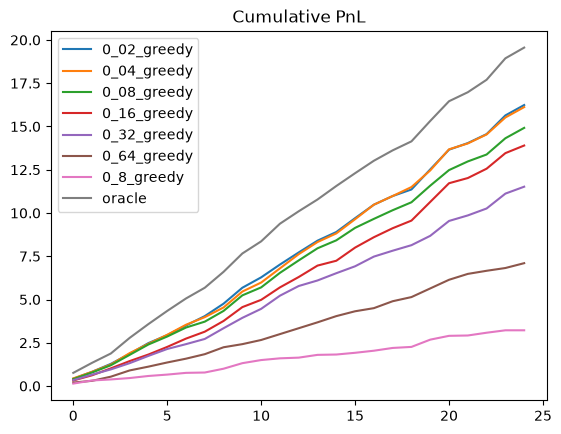

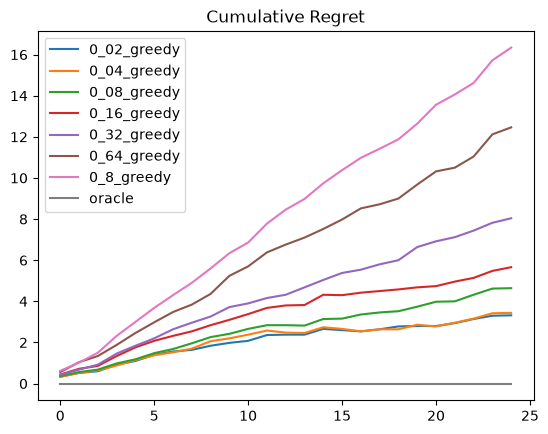

In [14]:
plot_PnL_curves("optimal_eps_25")
plot_regret_curves("optimal_eps_25")

$10$:

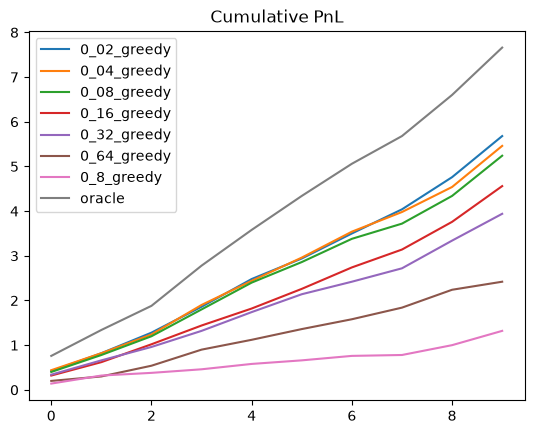

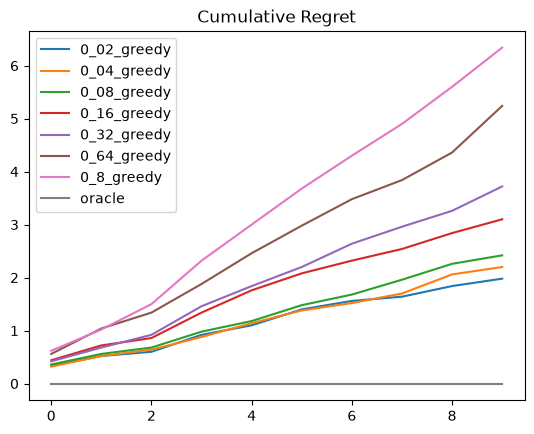

In [15]:
plot_PnL_curves("optimal_eps_10")
plot_regret_curves("optimal_eps_10")

Surprisingly, the ranking of the strategies are still the same. A possible reason for this is that the popping probabilities used in these games are pretty evenly spread across the $0-1$ interval, so a uniform prior doesn't do very bad. Let's try the edge cases where the probabilities are skewed high and low.

higher probabilities:


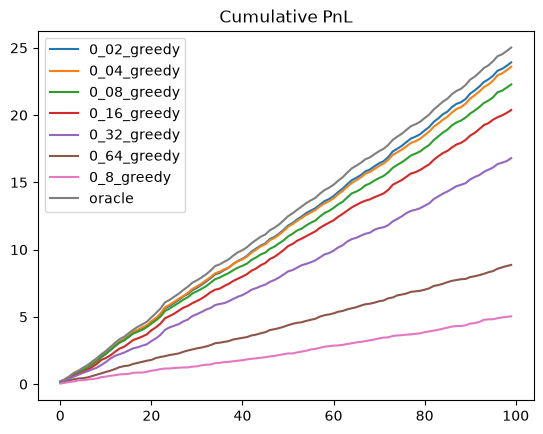

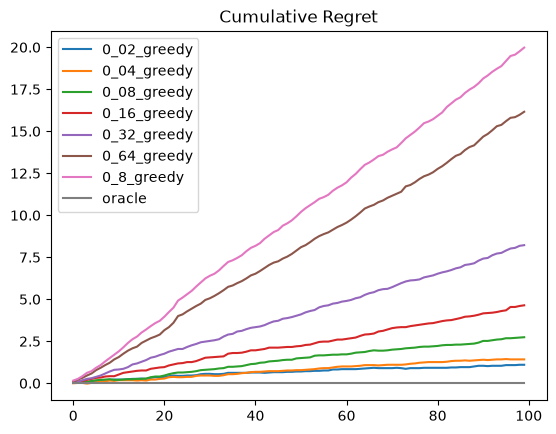

lower probabilities:


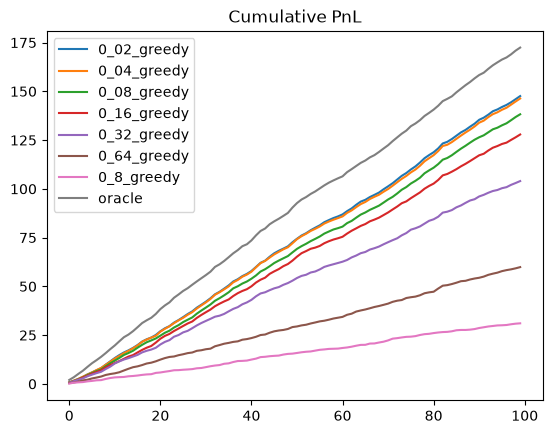

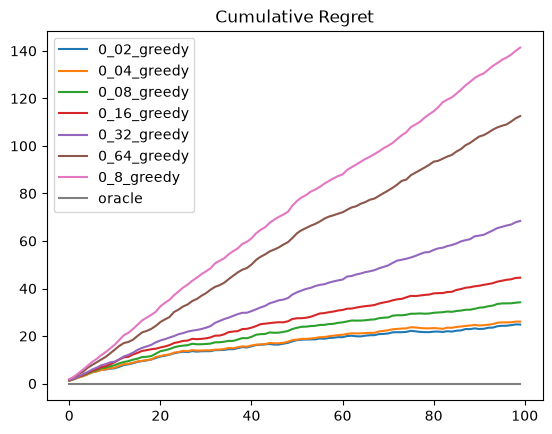

In [16]:
print("higher probabilities:")
plot_PnL_curves("optimal_eps_100_high_prob")
plot_regret_curves("optimal_eps_100_high_prob")
print("lower probabilities:")
plot_PnL_curves("optimal_eps_100_low_prob")
plot_regret_curves("optimal_eps_100_low_prob")

### Deciphering the Surprising results

Surprisingly, no matter how long the game is, and how the popping probabilities are distributed, a lower $\epsilon$ does better. From this we can infer that exploration is not really worth to do. More importantly though, it reminds us that during the exploitation phase the strategy is _still_ learning. And, these results seem to suggest that this learning is sufficient. Naturally, we should check the conjectured optimal $\epsilon=0$:

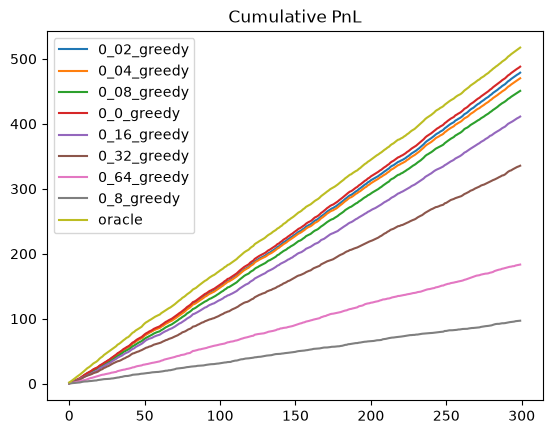

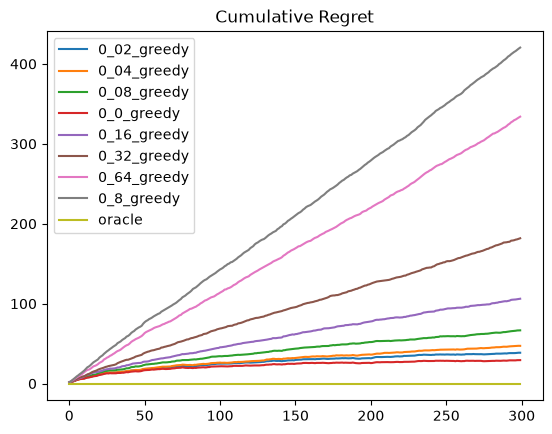

In [17]:
plot_PnL_curves("optimal_eps_300_solution")
plot_regret_curves("optimal_eps_300_solution")

As expected, this performs the best out of all the $\epsilon$-greedy strategies. Moreover, it seems like the Cumulative regret converges to a somewhat logarithmic-looking function. We will come back to this point.

<a id="thompson-sampling"></a>
## Thompson Sampling 

It may seem somwhat unreasonable or unjustified stress the balance between exploring and exploiting when we have just shown that exploring is not so efficient. However, we include this comparison between $0$-greedy and a new strategy using Thompson Sampling for future reference. Note that Thompson sampling is performing significantly worse than $0$-greedy.

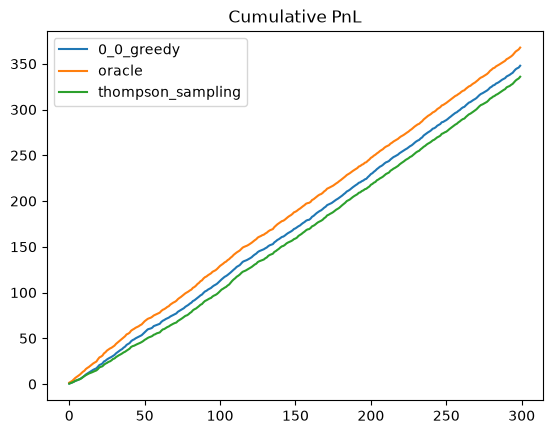

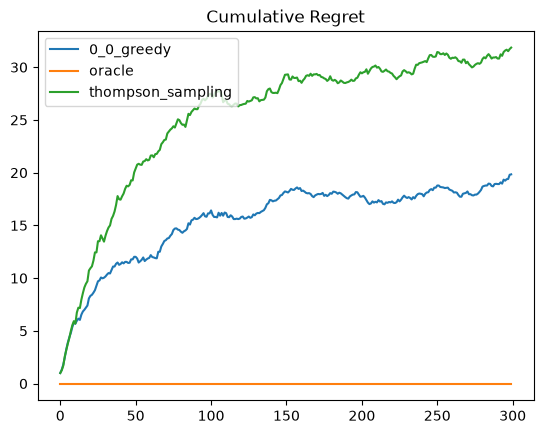

In [18]:
plot_PnL_curves("eps_greedy_vs_thompson")
plot_regret_curves("eps_greedy_vs_thompson")

## What's next?

Is $0$-greedy just the most optimal strategy? It seems like we have reached a dead-end here - like the Navier-Stokes millenium problem back in the days. And, what did we do about that? Jokes aside, it would be interesting to give the game description to the strongest AI models out there and let them design their own strategies (if not agentically play) and see how they do. We will continue this in the next notebook.